# Customer Segmentation Analysis Using K-Means Clustering

## Project Overview

This project focuses on segmenting customers based on their demographic characteristics and spending behavior.

The analysis uses exploratory data analysis and K-Means clustering to identify meaningful customer groups. These segments can help businesses understand customer preferences and develop targeted marketing strategies.

## Objectives

- Analyze customer demographics and spending behavior
- Explore relationships between customer characteristics
- Apply K-Means clustering for customer segmentation
- Determine the optimal number of customer segments
- Visualize and profile the identified customer groups
- Generate business insights and targeted recommendations

In [1]:
print("Customer Segmentation Project Started!")

Customer Segmentation Project Started!


## 1. Import Required Libraries

The following Python libraries are used for data manipulation, visualization, and customer segmentation.

- **Pandas** – Data manipulation and analysis
- **NumPy** – Numerical computations
- **Matplotlib** – Data visualization
- **Seaborn** – Statistical visualization
- **Scikit-learn** – Machine learning and clustering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the Dataset

The Mall Customers dataset contains information about customers, including their demographic characteristics and spending behavior.

The dataset includes the following attributes:

- Customer ID
- Gender
- Age
- Annual Income
- Spending Score

In [3]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 2.1 Preview the Dataset

The first few records are displayed to understand the structure and values of the dataset.

In [29]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Data Understanding

Before performing customer segmentation, the dataset is examined to understand its dimensions, columns, data types, and statistical characteristics.

### 3.1 Dataset Dimensions

The dimensions of the dataset are checked to determine the number of customer records and attributes.

In [4]:
df.shape


(200, 5)

### 3.2 Dataset Columns

The column names are examined to understand the variables available for analysis.

In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [6]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

### 3.3 Dataset Information

The dataset information is examined to identify data types and check for missing values.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


### 3.4 Statistical Summary

Descriptive statistics are used to understand the central tendency and distribution of numerical customer attributes.

In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 4. Data Cleaning

Data cleaning is performed to ensure that the dataset is suitable for analysis and clustering.

The following checks are performed:

- Missing values
- Duplicate records
- Unique values
- Data consistency

### 4.1 Checking for Missing Values

Missing values are checked across all columns. Missing data can affect the reliability of clustering results.

In [9]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### 4.2 Checking for Duplicate Records

Duplicate records are identified to prevent the same customer information from being counted multiple times.

In [10]:
df.duplicated().sum()

np.int64(0)

### 4.3 Checking Unique Values

Unique values are examined for categorical and identifier columns to understand the structure of the data.

In [11]:
df["Gender"].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [12]:
df["CustomerID"].nunique()

200

In [13]:
df = df.drop_duplicates()

### 4.4 Removing Duplicate Records

Duplicate records, if present, are removed from the dataset.

In [14]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (200, 5)


### 4.5 Preparing Column Names

Column names are simplified to make them easier to use during analysis and machine learning.

In [15]:
df = df.rename(columns={
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score"
})

In [16]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 200
Columns: 5
Missing values: 0
Duplicate rows: 0


## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand customer demographics, income levels, spending behavior, and relationships between important variables.

The analysis includes:

- Gender distribution
- Age distribution
- Annual income distribution
- Spending score distribution
- Relationship between income and spending
- Relationship between age and spending
- Relationship between age and income
- Correlation analysis

### 5.1 Customer Distribution by Gender

This visualization shows the distribution of customers by gender.

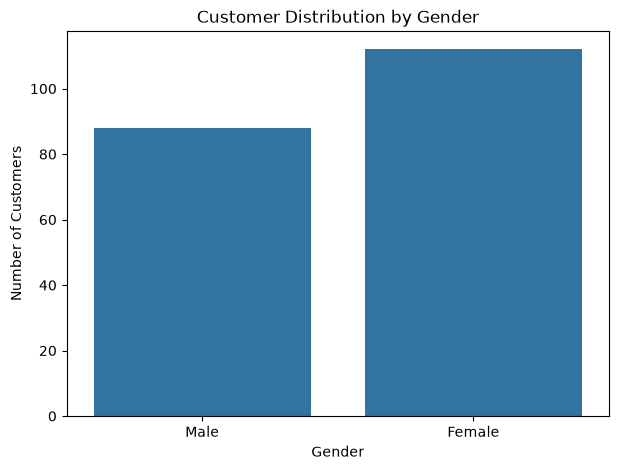

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Gender")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### 5.2 Age Distribution

The age distribution helps identify the age groups represented in the customer dataset.

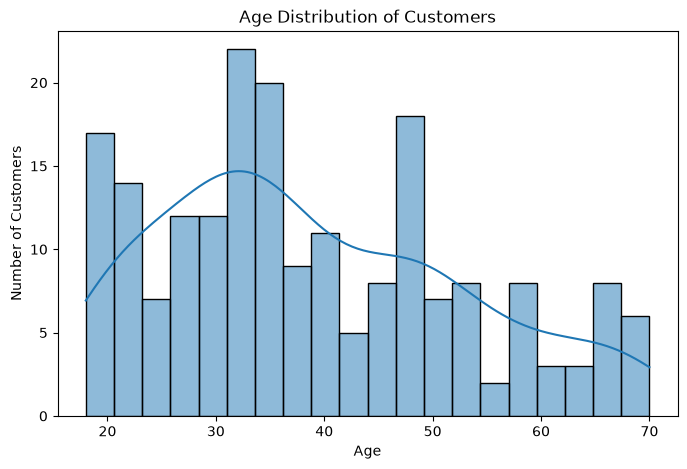

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### 5.3 Annual Income Distribution

This visualization shows how annual income is distributed among customers.

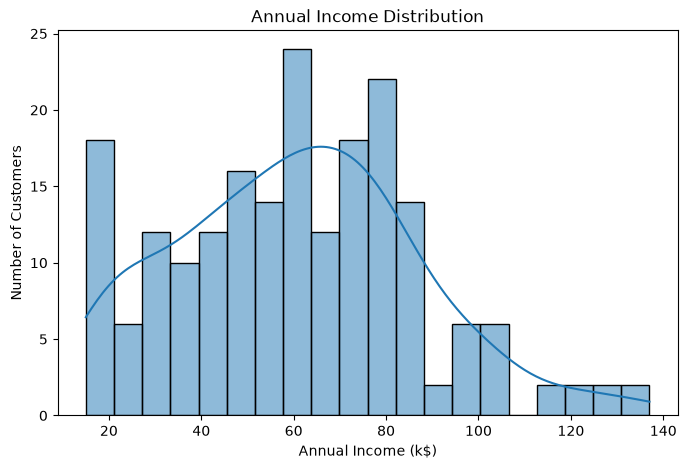

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Annual_Income",
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

### 5.4 Spending Score Distribution

The spending score represents customer spending behavior and is an important variable for segmentation.

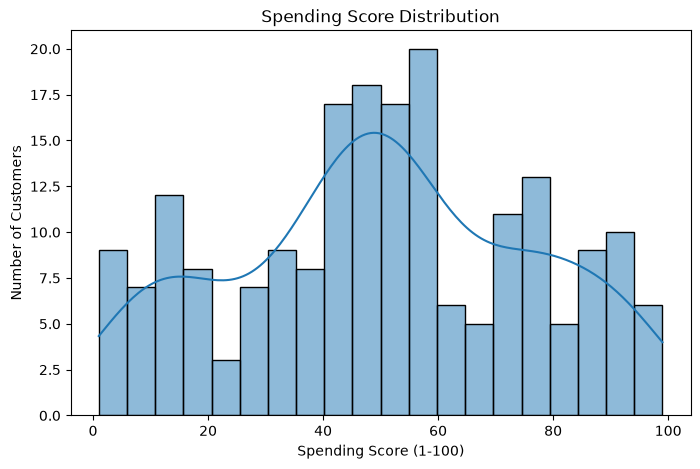

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Spending_Score",
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")

plt.show()

### 5.5 Annual Income vs Spending Score

The relationship between annual income and spending score is examined to identify potential customer groups with different spending behaviors.

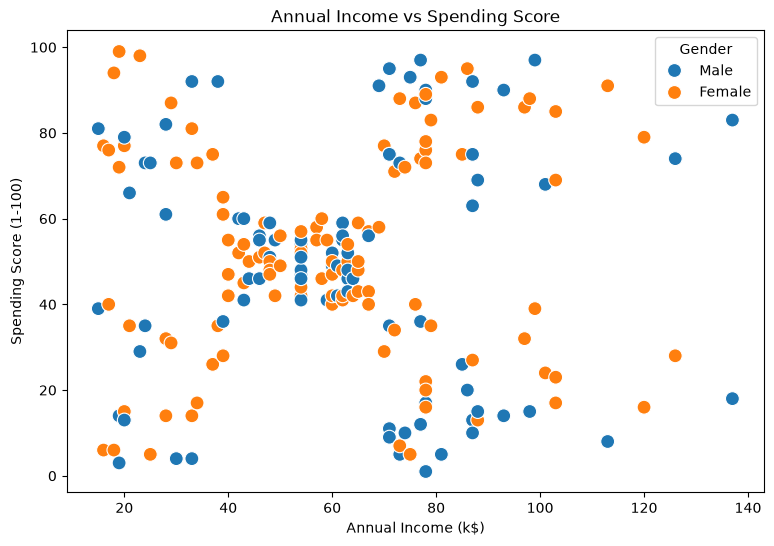

In [22]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Gender",
    s=100
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

### 5.6 Age vs Spending Score

This analysis explores the relationship between customer age and spending behavior.

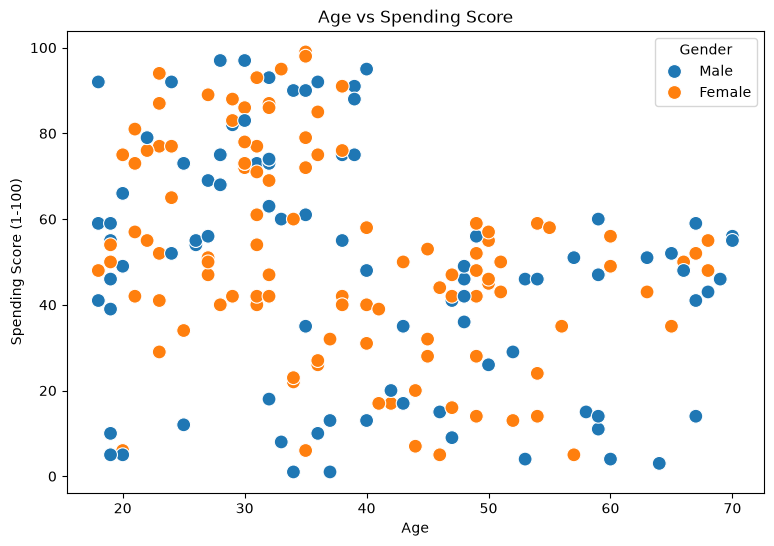

In [23]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending_Score",
    hue="Gender",
    s=100
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")

plt.show()

### 5.7 Age vs Annual Income

This visualization examines the relationship between customer age and annual income.

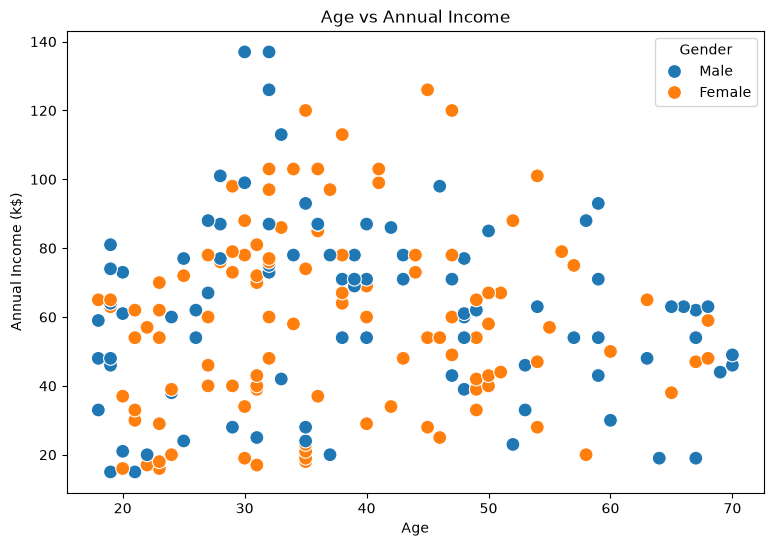

In [24]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Annual_Income",
    hue="Gender",
    s=100
)

plt.title("Age vs Annual Income")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")

plt.show()

### 5.8 Correlation Analysis

Correlation analysis is used to examine the relationships between age, annual income, and spending score.

In [25]:
correlation = df[
    ["Age", "Annual_Income", "Spending_Score"]
].corr()

correlation

,Age,Annual_Income,Spending_Score
Age,1.000000,-0.012398,-0.327227
Annual_Income,-0.012398,1.000000,0.009903
Spending_Score,-0.327227,0.009903,1.000000


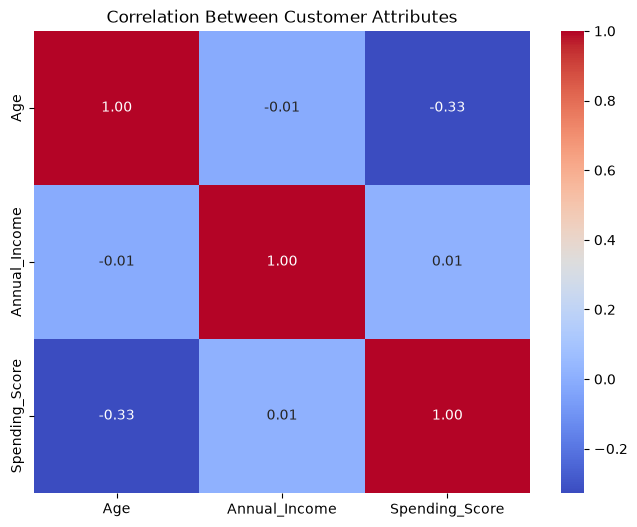

In [26]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Customer Attributes")

plt.show()

### 5.9 Summary Statistics

Key summary statistics are calculated to understand the average and range of customer characteristics.

In [27]:
print("Average Age:", round(df["Age"].mean(), 2))
print("Average Annual Income:", round(df["Annual_Income"].mean(), 2))
print("Average Spending Score:", round(df["Spending_Score"].mean(), 2))

Average Age: 38.85
Average Annual Income: 60.56
Average Spending Score: 50.2


In [28]:
print("Highest Annual Income:", df["Annual_Income"].max())
print("Lowest Annual Income:", df["Annual_Income"].min())
print("Highest Spending Score:", df["Spending_Score"].max())
print("Lowest Spending Score:", df["Spending_Score"].min())

Highest Annual Income: 137
Lowest Annual Income: 15
Highest Spending Score: 99
Lowest Spending Score: 1


# 6. Customer Segmentation Using K-Means Clustering

K-Means clustering is used to group customers with similar characteristics.

For this project, the following numerical features are used:

- Age
- Annual Income
- Spending Score

The clustering process consists of:

1. Feature selection
2. Feature standardization
3. Determining the optimal number of clusters
4. Applying K-Means clustering
5. Evaluating the clustering results
6. Visualizing customer segments
7. Profiling the identified segments

### 6.1 Feature Selection

Age, annual income, and spending score are selected as the primary features for customer segmentation.

These variables represent important demographic and behavioral characteristics of customers.

In [30]:
features = ["Age", "Annual_Income", "Spending_Score"]

X = df[features]

X.head()

,Age,Annual_Income,Spending_Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### 6.2 Feature Standardization

The selected features have different numerical scales. Standardization is therefore performed so that each feature contributes appropriately to the clustering process.

StandardScaler is used to transform the features to a common scale.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

### 6.3 Determining the Optimal Number of Clusters

The Elbow Method is used to identify a suitable number of clusters.

The method calculates the Within-Cluster Sum of Squares, represented by inertia, for different values of K.

The point where the reduction in inertia begins to slow down indicates a potential optimal number of clusters.

In [32]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

### Elbow Curve

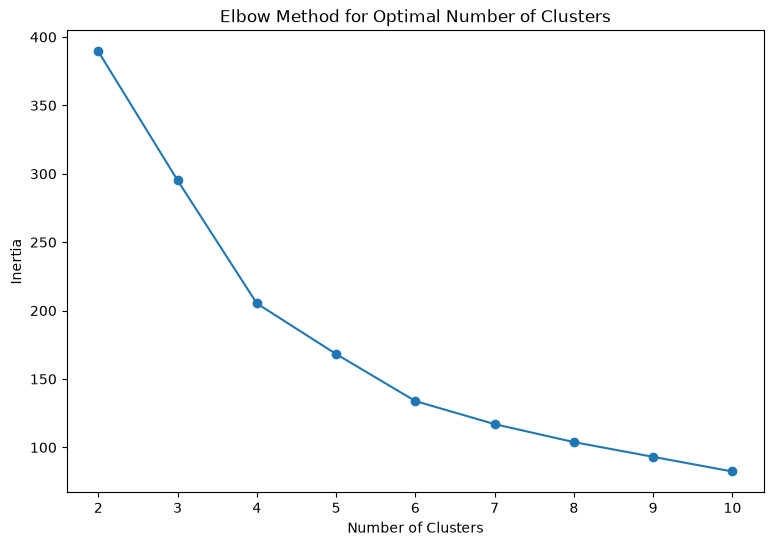

In [33]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))

plt.show()

### 6.4 Evaluating Cluster Quality Using Silhouette Score

The Silhouette Score is used as an additional method for evaluating the quality of clustering.

A higher silhouette score generally indicates that customers within the same cluster are more similar to each other while being more distinct from customers in other clusters.

In [34]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

### Silhouette Score Comparison

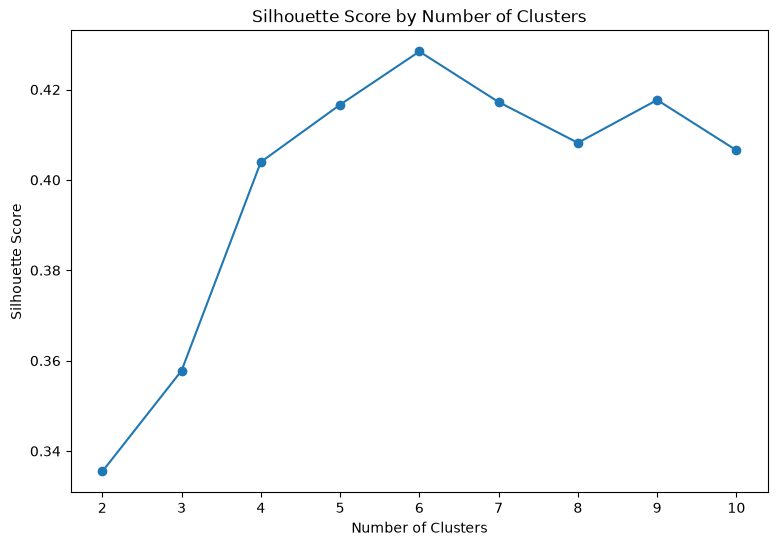

In [35]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))

plt.show()

### 6.5 Selecting the Number of Clusters

The silhouette scores are compared to identify the value of K that provides the strongest cluster separation.

The final value of K will be selected by considering both the Elbow Method and Silhouette Score, along with the business interpretability of the resulting customer groups.

In [36]:
best_k = range(2, 11)[np.argmax(silhouette_scores)]

print("Best K according to Silhouette Score:", best_k)

Best K according to Silhouette Score: 6


### 6.6 Applying the K-Means Clustering Model

Based on the evaluation using the Elbow Method and Silhouette Score, six clusters are selected for the final customer segmentation model.

The K-Means algorithm is then trained with six clusters, and each customer is assigned to a segment based on similarities in age, annual income, and spending score.

In [37]:
optimal_k = 6

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5


### 6.7 Customer Distribution Across Clusters

After applying K-Means clustering, the number of customers assigned to each cluster is examined to understand the size of each customer segment.

In [38]:
cluster_counts = df["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64

### Customer Count by Cluster

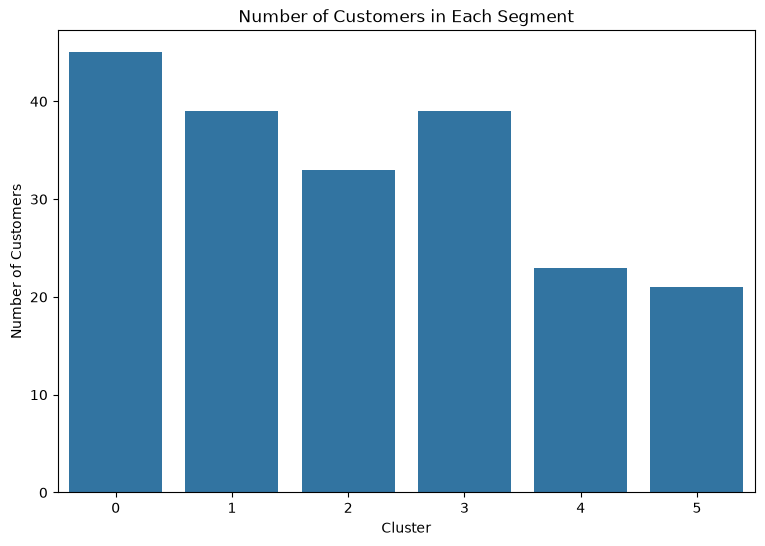

In [39]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

### 6.8 Visualizing Customer Segments

The customer segments are visualized using annual income and spending score.

This visualization helps identify differences in customer spending behavior across income levels.

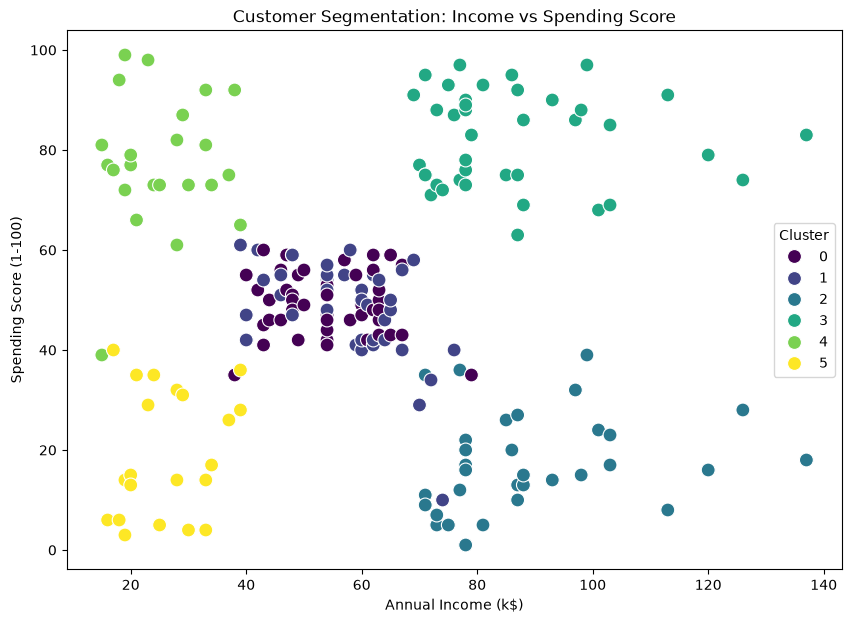

In [40]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.title("Customer Segmentation: Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")

plt.show()

### 6.9 Profiling Customer Segments

The characteristics of each customer segment are analyzed using average age, annual income, and spending score.

This allows each cluster to be interpreted from a business perspective.

In [41]:
cluster_summary = df.groupby("Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual_Income", "mean"),
    Average_Spending=("Spending_Score", "mean")
).round(2)

cluster_summary

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,45,56.33,54.27,49.07
1,39,26.79,57.10,48.13
2,33,41.94,88.94,16.97
3,39,32.69,86.54,82.13
4,23,25.00,25.26,77.61
5,21,45.52,26.29,19.38


### 6.10 Gender Distribution Across Customer Segments

Gender distribution is analyzed within each cluster to provide additional demographic information about the identified customer segments.

Gender is used for profiling the clusters and was not used as a numerical feature for K-Means clustering.

In [42]:
gender_by_cluster = pd.crosstab(
    df["Cluster"],
    df["Gender"]
)

gender_by_cluster

Gender,Female,Male
Cluster,,
0,26,19
1,25,14
2,14,19
3,21,18
4,13,10
5,13,8


In [43]:
gender_percentage = pd.crosstab(
    df["Cluster"],
    df["Gender"],
    normalize="index"
).round(2) * 100

gender_percentage

Gender,Female,Male
Cluster,,
0,58.0,42.0
1,64.0,36.0
2,42.0,58.0
3,54.0,46.0
4,57.0,43.0
5,62.0,38.0


### 6.11 Comparison of Customer Segment Characteristics

The average age, annual income, and spending score of each cluster are compared to identify the defining characteristics of the customer segments.

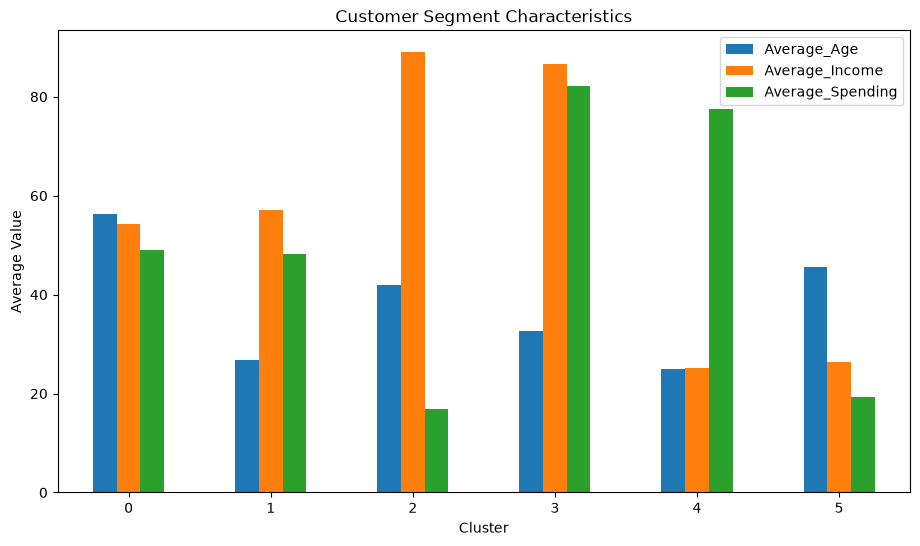

In [44]:
cluster_summary[
    ["Average_Age", "Average_Income", "Average_Spending"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Customer Segment Characteristics")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

In [45]:
segment_profile = cluster_summary.copy()

segment_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,45,56.33,54.27,49.07
1,39,26.79,57.10,48.13
2,33,41.94,88.94,16.97
3,39,32.69,86.54,82.13
4,23,25.00,25.26,77.61
5,21,45.52,26.29,19.38


In [46]:
segment_profile.sort_values(
    by="Average_Spending",
    ascending=False
)

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
3,39,32.69,86.54,82.13
4,23,25.00,25.26,77.61
0,45,56.33,54.27,49.07
1,39,26.79,57.10,48.13
5,21,45.52,26.29,19.38
2,33,41.94,88.94,16.97


## 7. Customer Segment Analysis

The six customer clusters are analyzed in detail to understand their demographic characteristics, income levels, spending behavior, and overall customer profile.

The objective is to translate the clustering results into meaningful customer segments that can support business and marketing decisions.

In [47]:
segment_profile = df.groupby("Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual_Income", "mean"),
    Average_Spending=("Spending_Score", "mean")
).round(2)

segment_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,45,56.33,54.27,49.07
1,39,26.79,57.10,48.13
2,33,41.94,88.94,16.97
3,39,32.69,86.54,82.13
4,23,25.00,25.26,77.61
5,21,45.52,26.29,19.38


### 7.1 Segment Ranking by Spending Behavior

Customer segments are ranked according to their average spending score to identify high-value and low-engagement groups.

In [48]:
segment_profile.sort_values(
    by="Average_Spending",
    ascending=False
)

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
3,39,32.69,86.54,82.13
4,23,25.00,25.26,77.61
0,45,56.33,54.27,49.07
1,39,26.79,57.10,48.13
5,21,45.52,26.29,19.38
2,33,41.94,88.94,16.97


### 7.2 Segment Ranking by Annual Income

Customer segments are ranked according to their average annual income to understand the economic characteristics of each segment.

In [49]:
segment_profile.sort_values(
    by="Average_Income",
    ascending=False
)

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
2,33,41.94,88.94,16.97
3,39,32.69,86.54,82.13
1,39,26.79,57.10,48.13
0,45,56.33,54.27,49.07
5,21,45.52,26.29,19.38
4,23,25.00,25.26,77.61


### 7.3 Heatmap of Customer Segment Characteristics

A heatmap is used to compare the average characteristics of the six customer segments and identify differences in age, income, and spending behavior.

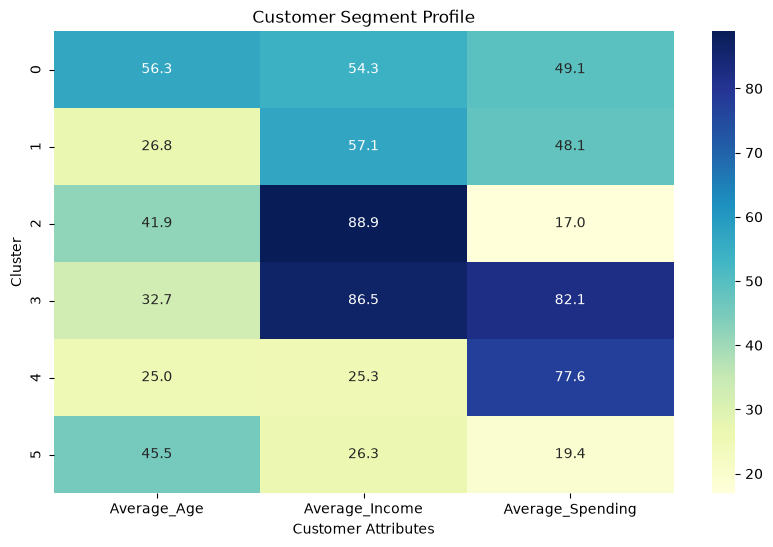

In [50]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    segment_profile[
        ["Average_Age", "Average_Income", "Average_Spending"]
    ],
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Customer Segment Profile")
plt.xlabel("Customer Attributes")
plt.ylabel("Cluster")

plt.show()

### 7.4 Gender Composition of Customer Segments

Gender composition is examined within each customer segment to provide additional demographic insights.

Gender is used for segment profiling rather than as a clustering feature.

In [51]:
gender_by_cluster = pd.crosstab(
    df["Cluster"],
    df["Gender"]
)

gender_by_cluster

Gender,Female,Male
Cluster,,
0,26,19
1,25,14
2,14,19
3,21,18
4,13,10
5,13,8


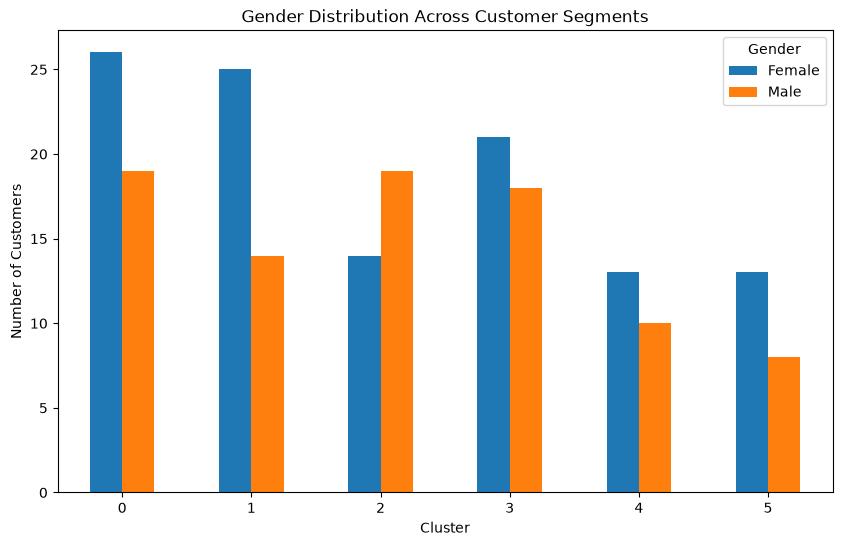

In [52]:
gender_by_cluster.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Gender Distribution Across Customer Segments")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

### 7.5 Identifying Segment Characteristics

The average income and spending score of each cluster are compared with the overall customer averages.

This helps classify the segments according to their relative income and spending behavior.

In [53]:
overall_income = df["Annual_Income"].mean()
overall_spending = df["Spending_Score"].mean()

print("Overall Average Income:", round(overall_income, 2))
print("Overall Average Spending Score:", round(overall_spending, 2))

Overall Average Income: 60.56
Overall Average Spending Score: 50.2


In [54]:
for cluster in segment_profile.index:
    income = segment_profile.loc[cluster, "Average_Income"]
    spending = segment_profile.loc[cluster, "Average_Spending"]
    
    print(f"\nCluster {cluster}")
    
    if income >= overall_income:
        print("Income Level: Above Average")
    else:
        print("Income Level: Below Average")
        
    if spending >= overall_spending:
        print("Spending Level: Above Average")
    else:
        print("Spending Level: Below Average")


Cluster 0
Income Level: Below Average
Spending Level: Below Average

Cluster 1
Income Level: Below Average
Spending Level: Below Average

Cluster 2
Income Level: Above Average
Spending Level: Below Average

Cluster 3
Income Level: Above Average
Spending Level: Above Average

Cluster 4
Income Level: Below Average
Spending Level: Above Average

Cluster 5
Income Level: Below Average
Spending Level: Below Average


### 7.6 Customer Segment Business Interpretation

Based on the cluster characteristics, each customer segment is assigned a meaningful business category. These categories help identify customer behavior and support targeted marketing strategies.

In [55]:
segment_names = {
    0: "Mature Average Customers",
    1: "Young Average Customers",
    2: "High-Income Low-Spending Customers",
    3: "High-Value Customers",
    4: "Young High-Spending Customers",
    5: "Low-Income Low-Spending Customers"
}

df["Segment"] = df["Cluster"].map(segment_names)

df[["CustomerID", "Age", "Annual_Income", "Spending_Score", "Cluster", "Segment"]].head(10)

,CustomerID,Age,Annual_Income,Spending_Score,Cluster,Segment
0,1,19,15,39,4,Young High-Spending Customers
1,2,21,15,81,4,Young High-Spending Customers
2,3,20,16,6,5,Low-Income Low-Spending Customers
3,4,23,16,77,4,Young High-Spending Customers
4,5,31,17,40,5,Low-Income Low-Spending Customers
5,6,22,17,76,4,Young High-Spending Customers
6,7,35,18,6,5,Low-Income Low-Spending Customers
7,8,23,18,94,4,Young High-Spending Customers
8,9,64,19,3,5,Low-Income Low-Spending Customers
9,10,30,19,72,4,Young High-Spending Customers


### 7.7 Final Customer Segment Profile

The final segment profile combines the cluster information with business-friendly segment names. This provides a clear overview of the size, demographics, income, and spending behavior of each customer segment.

In [56]:
final_segment_profile = df.groupby(
    ["Cluster", "Segment"]
).agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual_Income", "mean"),
    Average_Spending=("Spending_Score", "mean")
).round(2)

final_segment_profile

,,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,Segment,,,,
0,Mature Average Customers,45,56.33,54.27,49.07
1,Young Average Customers,39,26.79,57.10,48.13
2,High-Income Low-Spending Customers,33,41.94,88.94,16.97
3,High-Value Customers,39,32.69,86.54,82.13
4,Young High-Spending Customers,23,25.00,25.26,77.61
5,Low-Income Low-Spending Customers,21,45.52,26.29,19.38


### 7.8 Customer Segment Distribution

The distribution of customers across the six segments is visualized to identify the largest and smallest customer groups.

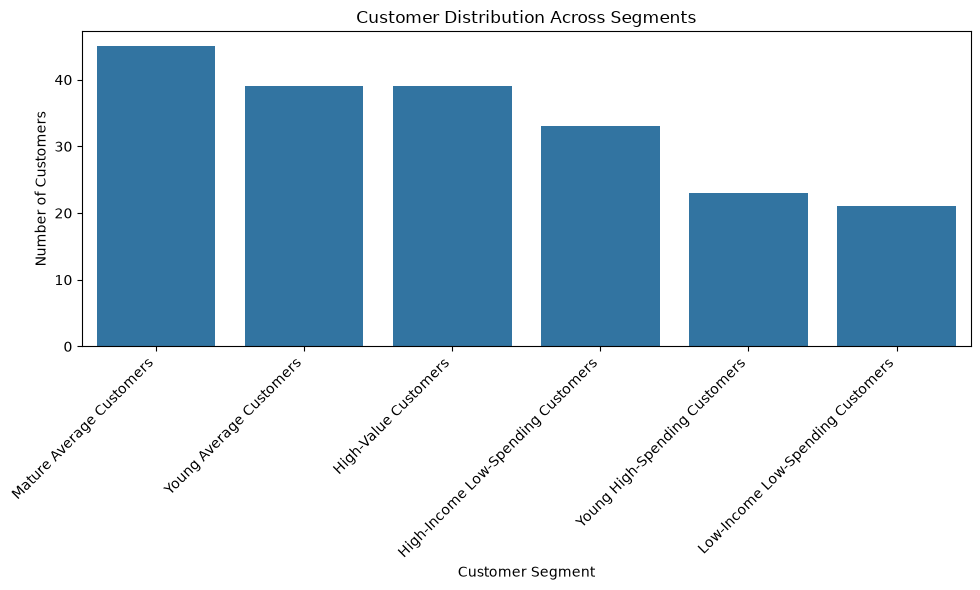

In [57]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Segment",
    order=df["Segment"].value_counts().index
)

plt.title("Customer Distribution Across Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 7.9 Income vs Spending by Customer Segment

The relationship between annual income and spending score is visualized using the identified customer segments. This helps distinguish high-value, low-spending, and high-spending customer groups.

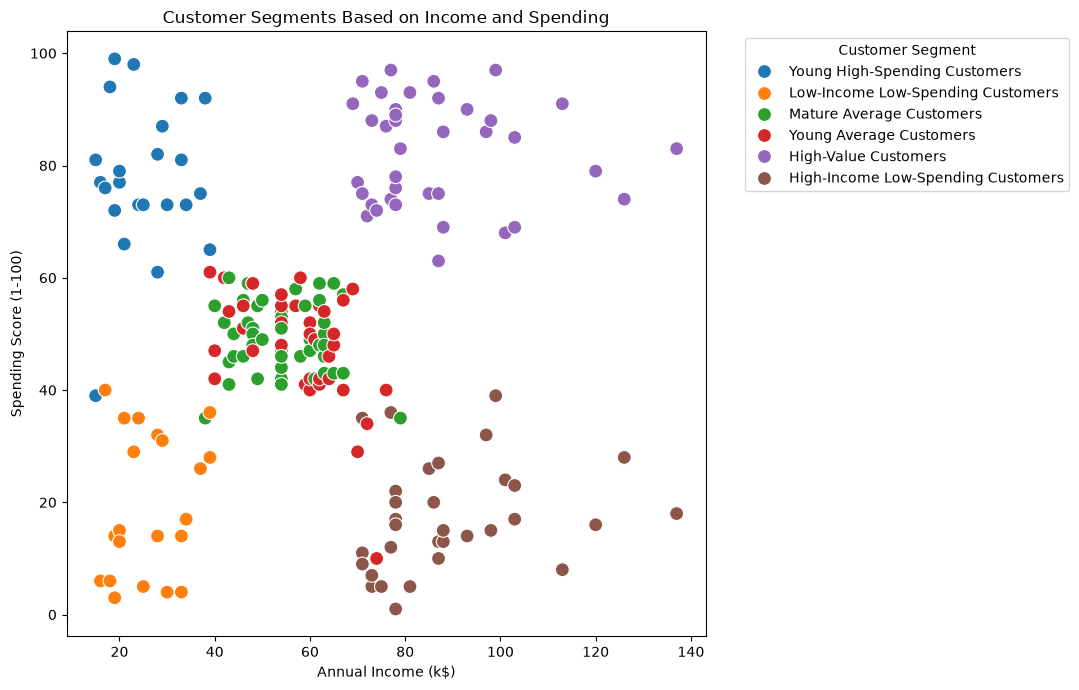

In [58]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Segment",
    s=100
)

plt.title("Customer Segments Based on Income and Spending")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Customer Segment", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### 7.10 Business Recommendations

The customer segmentation results can be used to develop targeted marketing strategies for different customer groups.

- **Mature Average Customers:** Introduce loyalty programs, personalized recommendations, and products suitable for mature customers.

- **Young Average Customers:** Use digital marketing, loyalty rewards, and engagement campaigns to increase customer spending.

- **High-Income Low-Spending Customers:** Provide personalized offers, premium product recommendations, and exclusive promotions to encourage higher spending.

- **High-Value Customers:** Prioritize this segment with VIP programs, premium services, exclusive offers, and personalized customer experiences.

- **Young High-Spending Customers:** Offer attractive discounts, affordable product bundles, and promotional campaigns to retain their high spending behavior.

- **Low-Income Low-Spending Customers:** Focus on value-for-money products, discounts, and budget-friendly offers.

Customer segmentation allows businesses to move from a one-size-fits-all marketing strategy toward more personalized customer engagement.

### 7.11 Exporting the Customer Segmentation Results

The final customer dataset containing cluster assignments and segment names is exported as a CSV file. This file can be used for further analysis and dashboard development.

In [59]:
df.to_csv("../data/customer_segments.csv", index=False)

print("Customer segmentation dataset exported successfully.")

Customer segmentation dataset exported successfully.
